In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 76.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=59dab15b8368271cdbdde0270cbab71ba40b629a6411865087a6499f36317ffb
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# Does not require entanglement; it relies on the "no-cloning theorem",
# meaning any eavesdropper trying to intercept the qubits will introduce
# detectable disturbances. (for my reference)

# This notebook is for a simulation of the protocol without an attacker.


In [3]:
# ============================================================
# QUANTUM RANDOM NUMBER GENERATION
# ============================================================

def generate_quantum_random_bits(n):
    """
    Generate n random bits using quantum measurements.
    Creates |+⟩ = √½(|0⟩ + |1⟩) and measures to get random 0 or 1.
    """
    qc = QuantumCircuit(n, n)

    # Put all qubits in |+⟩ state
    for i in range(n):
        qc.h(i)

    # Measure all qubits
    qc.measure(range(n), range(n))

    # Run circuit
    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    # Get the result string and convert to list of ints
    bitstring = list(counts.keys())[0]
    return [int(bit) for bit in reversed(bitstring)]

In [4]:
# ============================================================
# BB84 PROTOCOL FUNCTIONS
# ============================================================

def alice_prepare_qubit(bit, basis):
    """
    Alice prepares a qubit to send to Bob.

    Encoding:
    - Z basis (0): bit 0 → |0⟩, bit 1 → |1⟩
    - X basis (1): bit 0 → |+⟩, bit 1 → |−⟩
    """
    qc = QuantumCircuit(1, 1)

    # Encode the bit value
    if bit == 1:
        qc.x(0)

    # Apply basis (H for X basis)
    if basis == 1:
        qc.h(0)

    return qc


def bob_measure_qubit(qc, basis):
    """
    Bob measures the qubit in his chosen basis.
    """
    # To measure in X basis, apply H first
    if basis == 1:
        qc.h(0)

    # Measure
    qc.measure(0, 0)

    # Run circuit
    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    return int(list(counts.keys())[0])


def create_shared_key(alice_bits, alice_bases, bob_bases, bob_results):
    """
    Compare bases and keep bits where they match.
    This is called 'sifting' or 'basis reconciliation'.
    """
    alice_key = []
    bob_key = []
    matching_positions = []

    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])
            matching_positions.append(i)

    return alice_key, bob_key, matching_positions

In [18]:
# ============================================================
# VISUALIZATION FUNCTIONS
# ============================================================

def show_transmission_table(alice_bits, alice_bases, bob_bases, bob_results, matching_positions):
    """
    Display a clear table showing the entire transmission.
    """
    print("\n" + "="*70)
    print("BB84 TRANSMISSION DETAILS")
    print("="*70)
    print("\nPosition:      ", end="")
    for i in range(len(alice_bits)):
        print(f"{i:3d}", end=" ")

    print("\nAlice's bit:   ", end="")
    for bit in alice_bits:
        print(f"  {bit}", end=" ")

    print("\nAlice's basis: ", end="")
    for basis in alice_bases:
        print(f"  {'X' if basis == 1 else 'Z'}", end=" ")

    print("\nBob's basis:   ", end="")
    for basis in bob_bases:
        print(f"  {'X' if basis == 1 else 'Z'}", end=" ")

    print("\nBob measured:  ", end="")
    for result in bob_results:
        print(f"  {result}", end=" ")

    print("\nBases match?   ", end="")
    for i in range(len(alice_bits)):
        if i in matching_positions:
            print("  ✓", end=" ")
        else:
            print("  ✗", end=" ")
    print("\n")


def show_key_comparison(alice_key, bob_key):
    """
    Show the final shared keys.
    """
    print("="*70)
    print("FINAL SHARED KEY")
    print("="*70)
    print(f"\nAlice's key: {alice_key}")
    print(f"Bob's key:   {bob_key}")

    errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])

    if errors == 0:
        print("\n✓ Keys match perfectly! Secure communication established.")
    else:
        print(f"\n✗ Warning: {errors} error(s) detected!")

    print("\n" + "="*70)


def create_visualizations(n_bits, alice_key, bob_key, matching_positions):
    """
    Create helpful charts to understand BB84.
    """
    # 1. Basis reconciliation chart
    matching = len(matching_positions)
    discarded = n_bits - matching

    reconciliation = {
        'Kept (Same Basis)': matching,
        'Discarded (Different Basis)': discarded
    }

    # 2. Key composition
    zeros = alice_key.count(0)
    ones = alice_key.count(1)

    key_composition = {
        '0 bits': zeros,
        '1 bits': ones
    }

    # 3. Error analysis
    errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
    correct = len(alice_key) - errors

    accuracy = {
        'Correct bits': correct,
        'Errors': errors
    }

    # Display all charts
    print("\nVISUALIZATIONS\n")
    display(plot_histogram(reconciliation, title='1. Basis Reconciliation', color='skyblue'))
    display(plot_histogram(key_composition, title='2. Final Key Composition', color='lightgreen'))
    display(plot_histogram(accuracy, title='3. Key Accuracy (QBER)', color='coral'))

In [10]:
# ============================================================
# RUN BB84 PROTOCOL
# ============================================================

def run_bb84(n_bits=20):
    """
    Execute the complete BB84 protocol.
    """
    print("\n" + "="*70)
    print("RUNNING BB84 QUANTUM KEY DISTRIBUTION")
    print("="*70)
    print(f"\nSending {n_bits} qubits...\n")

    # Step 1: Generate random choices using quantum measurements
    alice_bits = generate_quantum_random_bits(n_bits)
    alice_bases = generate_quantum_random_bits(n_bits)
    bob_bases = generate_quantum_random_bits(n_bits)

    # Step 2: Alice sends qubits, Bob measures them
    bob_results = []

    for i in range(n_bits):
        # Alice prepares qubit
        qc = alice_prepare_qubit(alice_bits[i], alice_bases[i])

        # Bob measures it
        result = bob_measure_qubit(qc, bob_bases[i])
        bob_results.append(result)

    # Step 3: Create shared key (basis reconciliation)
    alice_key, bob_key, matching_positions = create_shared_key(
        alice_bits, alice_bases, bob_bases, bob_results
    )

    # Step 4: Display results
    show_transmission_table(alice_bits, alice_bases, bob_bases, bob_results, matching_positions)
    show_key_comparison(alice_key, bob_key)

    # Step 5: Show statistics
    print("STATISTICS")
    print("="*70)
    print(f"Qubits sent: {n_bits}")
    print(f"Matching bases: {len(matching_positions)} ({len(matching_positions)/n_bits*100:.1f}%)")
    print(f"Final key length: {len(alice_key)} bits")

    errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
    error_rate = (errors / len(alice_key) * 100) if alice_key else 0
    print(f"Error rate (QBER): {error_rate:.2f}%")
    print("="*70)

    # Step 6: Visualizations
    create_visualizations(n_bits, alice_key, bob_key, matching_positions)

    return alice_key, bob_key


RUNNING BB84 QUANTUM KEY DISTRIBUTION

Sending 20 qubits...


BB84 TRANSMISSION DETAILS

Position:        0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19 
Alice's bit:     0   0   1   1   1   0   1   1   1   1   0   0   1   1   1   0   1   0   1   0 
Alice's basis:   Z   Z   X   X   Z   Z   Z   Z   Z   X   Z   X   X   X   X   X   X   Z   X   Z 
Bob's basis:     Z   Z   Z   Z   Z   X   Z   Z   Z   Z   Z   X   X   X   X   Z   X   Z   X   X 
Bob measured:    0   0   1   0   1   1   1   1   1   0   0   0   1   1   1   1   1   0   1   1 
Bases match?     ✓   ✓   ✗   ✗   ✓   ✗   ✓   ✓   ✓   ✗   ✓   ✓   ✓   ✓   ✓   ✗   ✓   ✓   ✓   ✗ 

FINAL SHARED KEY

Alice's key: [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]
Bob's key:   [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]

✓ Keys match perfectly! Secure communication established.

STATISTICS
Qubits sent: 20
Matching bases: 14 (70.0%)
Final key length: 14 bits
Error rate (QBER): 0.00%

VISUALIZATIONS



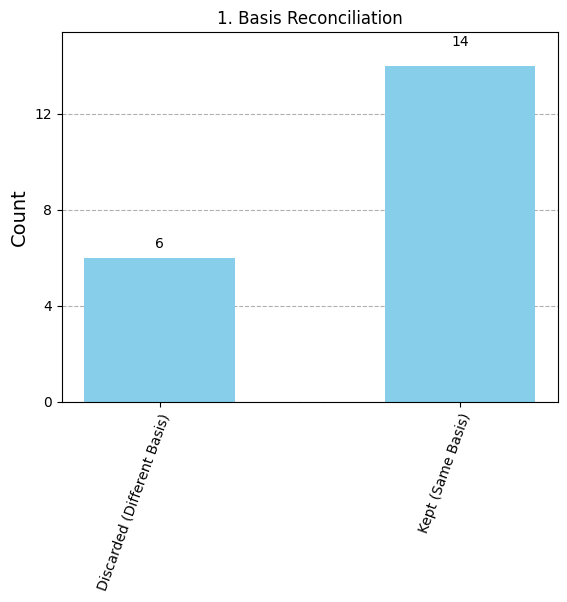

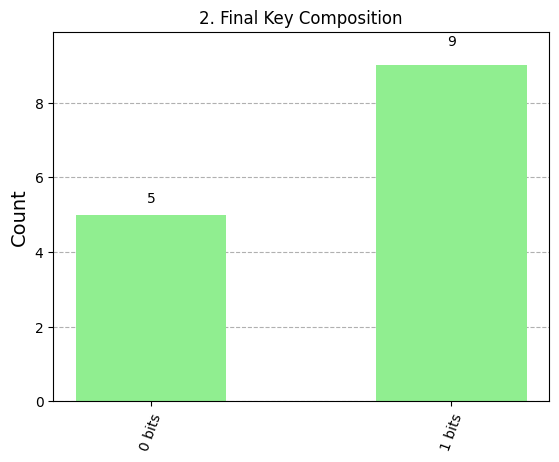

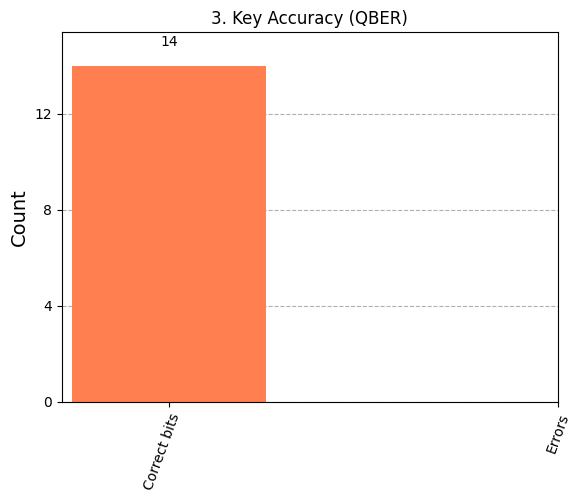

In [19]:
# Execute BB84 protocol
alice_key, bob_key = run_bb84(n_bits=20)